# Raport — Shembull 1  
## Eksperiment fizik: Lavjerrësi i thjeshtë

**Lënda:** Hyrje në Laborator  
**Kodi i laboratorit:** `LAB01`  
**Titulli:** `Lavjerrësi i thjeshtë`  
**Studenti / Studentja:** `Albert Einstein`  
**Grupi:** `1`  
**Data e zhvillimit të laboratorit:** `01-03-2026`  
**Data e dorëzimit:** `07-03-2026`  
**Pedagogu:** `ek`

---

## 1. Qëllimi

Qëllimi i këtij laboratori është të studiohet varësia e periodës së lëkundjes së një lavjerrësi të thjeshtë nga gjatësia e tij.  
Në veçanti, synohet të testohet marrëdhënia teorike midis $T$ dhe $L$, si dhe të vlerësohet nxitimi i rënies së lirë $g$ nga të dhënat eksperimentale.


## 2. Teoria

Për kënde të vogla lëkundjeje, perioda e pendulit të thjeshtë jipet nga:

$$
T = 2\pi \sqrt{\frac{L}{g}}.
$$

Duke e ngritur në katror, merret:

$$
T^2 = \frac{4\pi^2}{g}L.
$$

Pra, nëse paraqesim $T^2$ në funksion të $L$, pritet të marrim një varësi lineare. 
$$
T^2 = aL + b,
$$

Nga pjerrësia $a$ e drejtëzës mund të vlerësojmë:

$$
g = \frac{4\pi^2}{a}.
$$


## 3. Aparatura / software


- Lavjerrësi
  * sferë metalike
  * fije e hollë
  * mbajtëse/varëse
- Python 3
- `numpy`
- `pandas`
- `matplotlib`


![](figs/simple-pendulum.jpg)


Të dhënat ndodhen në folder `data/` në skedarin:

`penduli_perioda_vs_gjatesia.csv`


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (6, 4)

df = pd.read_csv("data/penduli_perioda_vs_gjatesia.csv")


## 4. Procedura eksperimentale / matëse

U morën disa vlera të gjatësisë së pendulit dhe për secilën u regjistrua perioda përkatëse.  
Të dhënat e paraqitura këtu shërbejnë si shembull i analizës së plotë të një raporti laboratorik.

Hapat kryesorë të analizës janë:
1. ngarkimi i të dhënave,
2. llogaritja e $T^2$,
3. përshtatja lineare e grafikut $T^2(L)$,
4. vlerësimi i $g$,
5. analiza e mbetjeve.


## 5. Të dhënat e papërpunuara


In [2]:
df


,gjatesia_m,perioda_s,u_perioda_s
0,0.2,0.9063,0.03
1,0.3,1.0676,0.03
2,0.4,1.2913,0.03
3,0.5,1.4467,0.03
4,0.6,1.4954,0.03
5,0.8,1.7552,0.03
6,1.0,2.0099,0.03


## 6. Përpunimi paraprak i të dhënave

Llogarisim madhësinë e prejardhur $T^2$, e cila na lejon të kalojmë nga modeli jo-linear në një formë lineare.


In [4]:
df["T2_s2"] = df["perioda_s"]**2
df


,gjatesia_m,perioda_s,u_perioda_s,T2_s2
0,0.2,0.9063,0.03,0.821380
1,0.3,1.0676,0.03,1.139770
2,0.4,1.2913,0.03,1.667456
3,0.5,1.4467,0.03,2.092941
4,0.6,1.4954,0.03,2.236221
5,0.8,1.7552,0.03,3.080727
6,1.0,2.0099,0.03,4.039698


## 7. Analiza e të dhënave


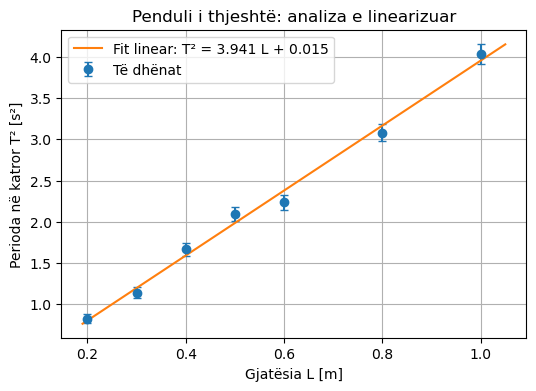

Pjerrësia a = 3.9409 s^2/m
Prerja b = 0.0147 s^2
Vlerësimi i g = 10.018 m/s^2


In [8]:
a, b = np.polyfit(df["gjatesia_m"], df["T2_s2"], 1)
g_vleresuar = 4*np.pi**2 / a

xfit = np.linspace(df["gjatesia_m"].min()*0.95, df["gjatesia_m"].max()*1.05, 200)
yfit = a*xfit + b

plt.errorbar(
    df["gjatesia_m"],
    df["T2_s2"],
    yerr=2*df["perioda_s"]*df["u_perioda_s"],
    fmt="o",
    capsize=3,
    label="Të dhënat"
)
plt.plot(xfit, yfit, label=f"Fit linear: T² = {a:.3f} L + {b:.3f}")
plt.xlabel("Gjatësia L [m]")
plt.ylabel("Perioda në katror T² [s²]")
plt.title("Penduli i thjeshtë: analiza e linearizuar")
plt.grid(True)
plt.legend()
plt.show()

print(f"Pjerrësia a = {a:.4f} s^2/m")
print(f"Prerja b = {b:.4f} s^2")
print(f"Vlerësimi i g = {g_vleresuar:.3f} m/s^2")


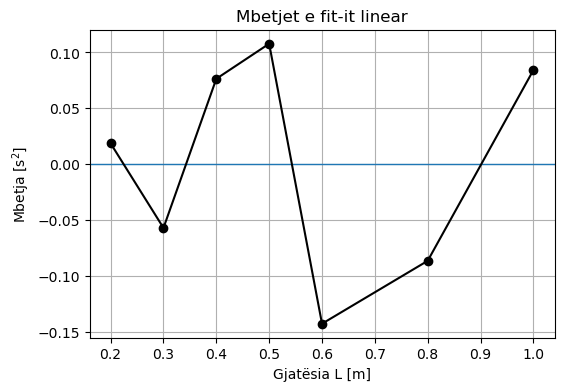

In [11]:
df["T2_fit_s2"] = a*df["gjatesia_m"] + b
df["mbetja_s2"] = df["T2_s2"] - df["T2_fit_s2"]

plt.axhline(0, linewidth=1)
plt.plot(df["gjatesia_m"], df["mbetja_s2"], "o-k")
plt.xlabel("Gjatësia L [m]")
plt.ylabel(r"Mbetja $\rm [s^2]$")
plt.title("Mbetjet e fit-it linear")
plt.grid(True)
plt.show()


## 8. Pasiguritë dhe burimet e gabimeve

Burimet kryesore të pasigurive në këtë experiment janë:
- matja e gjatësisë së lavjerrësit,
- pasiguria në matjen e kohës / periodës,
- devijimi nga kushti i këndeve të vogla,
- forcat e fërkimit,
- numri i kufizuar i matjeve eksperimentale (numër i vogël pikash).

Një prerje jo-zero e drejtëzës mund të tregojë ndikim të gabimeve sistematike ose kufizime të modelit të idealizuar.


## 9. Diskutimi

Të dhënat tregojnë sjellje afërsisht lineare të $T^2$ në funksion të $L$, në përputhje me teorinë e lavjerrësit të thjeshtë për kënde të vogla.  
Mbetjet nuk tregojnë devijime shumë të mëdha, çka sugjeron se modeli linear është i arsyeshëm për këtë grup të dhënash.

Vlera e $g=10.02\,\mathrm{m/s^2}$ e vlerësuar nga fit-i është shume afer vlerës standarde $9.81\,\mathrm{m/s^2}$.


## 10. Përfundimi

Nga analiza e të dhënave u verifikua marrëdhënia teorike $T^2 \propto L$.  
Përmes përshtatjes lineare të grafikut $T^2(L)$ u vlerësua nxitimi i rënies së lirë $g$.  
...
